# Use active learning to improve a Toy FNN
In this lab, we will improve the FNN with active learning following two strategies:

1. MC Dropout

2. Max-Min Sampling

Where the first method is an **uncertainty based sampling**, while the second one is a **diversity based sampling**.

Unlike the example for GPR model where we add noise, here we don't use noise. That is because GPR can natually handle noise by adding a white noise kernel.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

### Define the target function
We do not use noise this time

In [2]:
def target_func(x):
  return np.sin(3*x)

### make training and test data

In [3]:
# training set
X = np.linspace(0, 2, 200)[:, None] # [:, None] adds another dimension, turns a vector to a matrix (pytorch wants matrices)
y = target_func(X)

# Test set
X_test = np.linspace(0, 2, 100)[:, None]
y_test = target_func(X_test)

### Define a simple FNN
In this example, we add another feature to the neural network: the dropout.

Adding `nn.Dropout(0.1)` after a layer, means that the model will randomly pick 10% of the neurons in this layer and turn off their weights (won't be passed onto the next layer).

However, because in each forward pass, the neurons to be turned off are random, so we can still train the weights of all neurons.

In [4]:
class FNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Dropout(0.08), # the dropout ratio is 8%
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.08),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

### Write a training wrapper

In [6]:
def train_nn(model, X_train, y_train, epochs=100, lr=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        loss.backward()
        optimizer.step()

## Now let's add the MC dropout for active learning

First, divide the training data into labeled and unlabeled pools

In [7]:
# np.random.seed(0)
# initialize labeled/unlabeled pools
idx = np.random.choice(len(X), 5, replace=False)
X_labeled, y_labeled = X[idx], y[idx]
X_unlabeled = np.delete(X, idx, axis=0)
y_unlabeled = np.delete(y, idx, axis=0)

In [8]:
# Convert to torch tensors
X_labeled_t = torch.tensor(X_labeled, dtype=torch.float32)
y_labeled_t = torch.tensor(y_labeled, dtype=torch.float32)
X_unlabeled_t = torch.tensor(X_unlabeled, dtype=torch.float32)

Text(0.5, 1.0, 'Active Learning with MC Dropout')

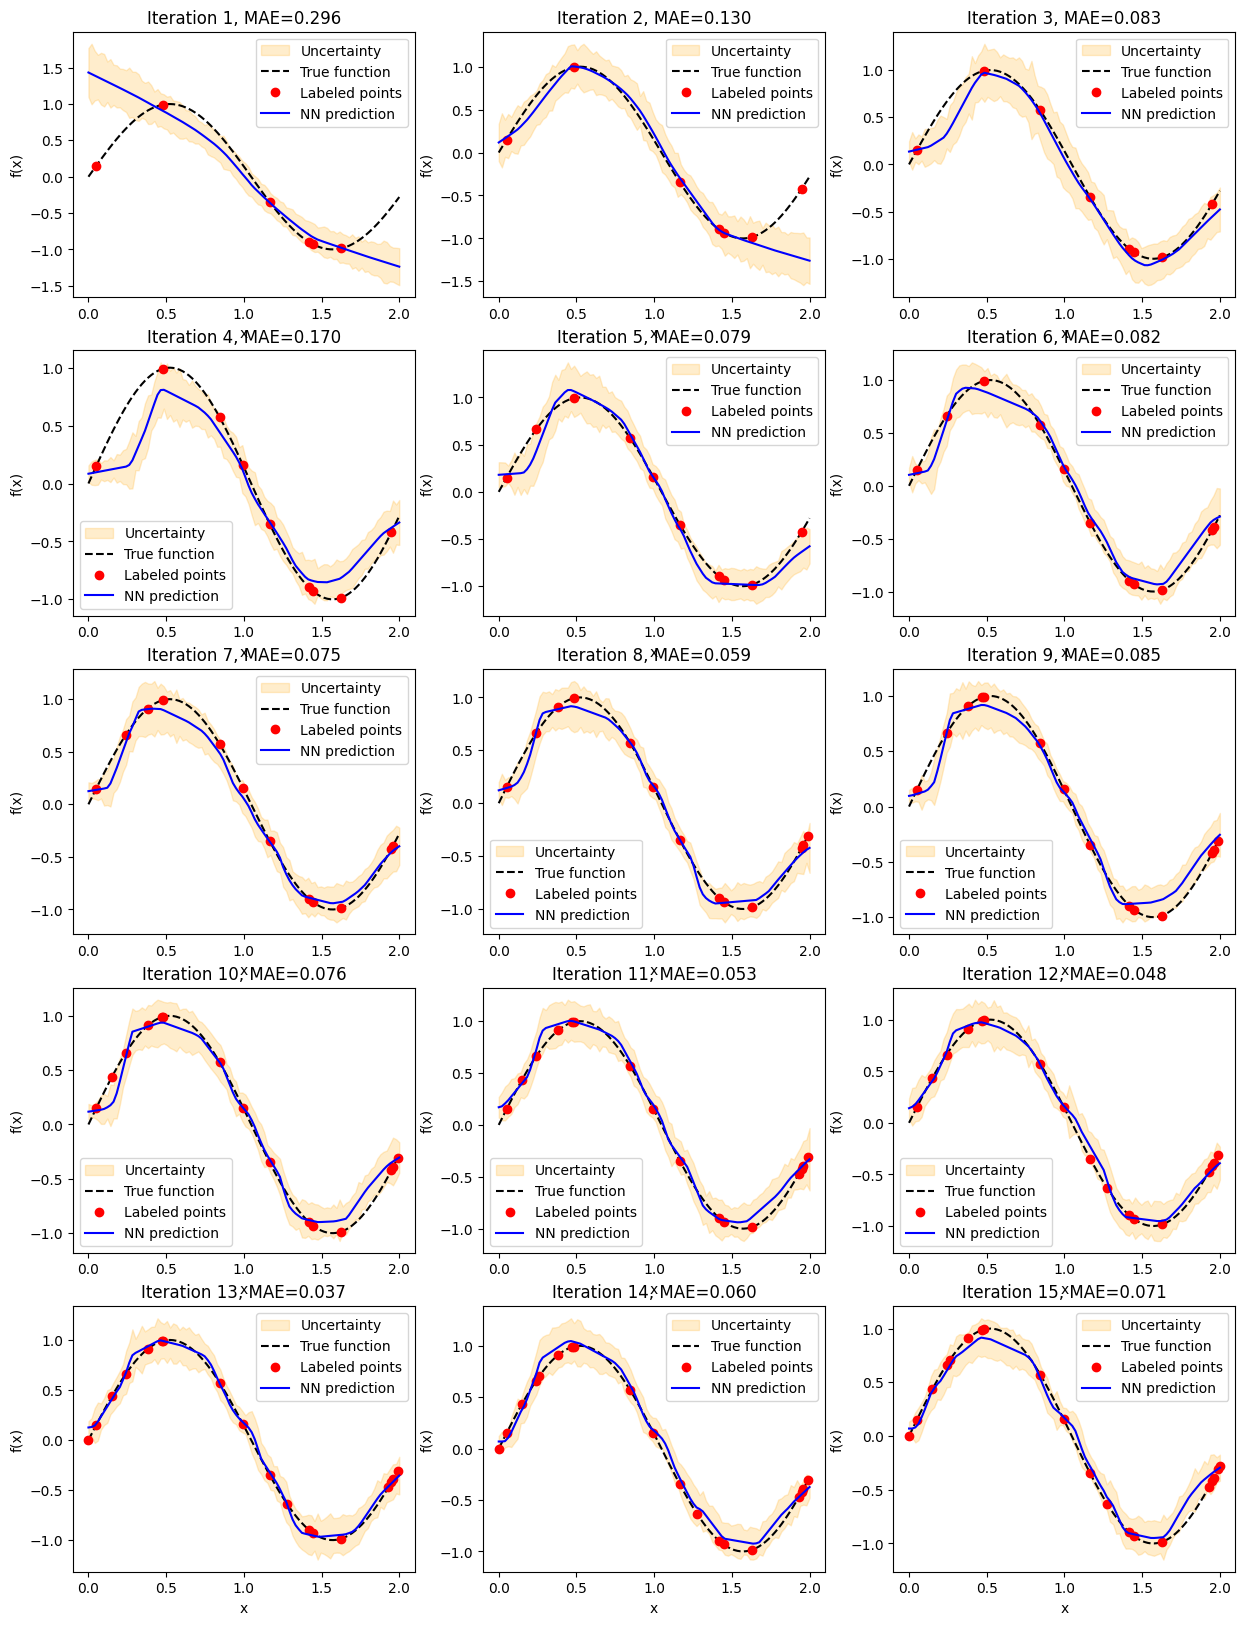

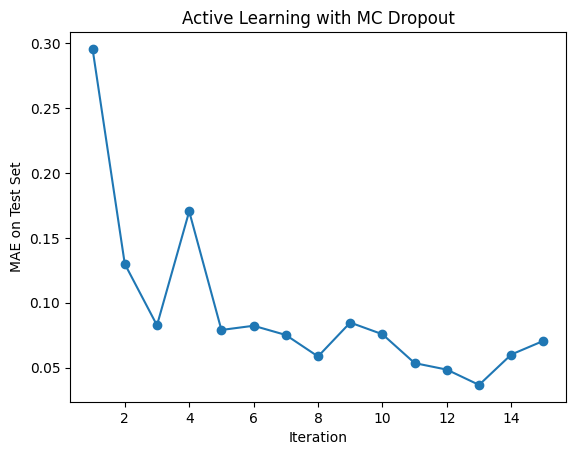

In [10]:
num_iter_al = 15 # active learning iteration number
mc_samples = 50  # for MC dropout
mae_list = []
# set up the plotting
# setting up the plotting
nx_panel = 3
ny_panel = num_iter_al//nx_panel + int(bool(num_iter_al%nx_panel))
fig, axes = plt.subplots(ny_panel, nx_panel, figsize=(nx_panel*5, ny_panel*4))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# initialize model
model = FNN()

# start AL loop
for iteration in range(num_iter_al):
    # Train NN
    train_nn(model, X_labeled_t, y_labeled_t)

    # MC Dropout predictions on unlabeled pool
    model.train()  # training mode on, keep dropout on
    preds = []
    for _ in range(mc_samples):
        preds.append(model(X_unlabeled_t).detach().numpy()) # detach() creates a mew tensor and stops gradient tracking
    preds = np.array(preds).squeeze()
    mean_pred = preds.mean(axis=0)
    std_pred = preds.std(axis=0)

    # Select next point: largest std
    query_idx = np.argmax(std_pred)
    X_new = X_unlabeled[query_idx:query_idx+1]
    y_new = y_unlabeled[query_idx:query_idx+1]

    # Add new point to labeled set
    X_labeled = np.vstack([X_labeled, X_new])
    y_labeled = np.vstack([y_labeled, y_new])
    X_labeled_t = torch.tensor(X_labeled, dtype=torch.float32)
    y_labeled_t = torch.tensor(y_labeled, dtype=torch.float32)

    # Remove from unlabeled set
    X_unlabeled = np.delete(X_unlabeled, query_idx, axis=0)
    y_unlabeled = np.delete(y_unlabeled, query_idx, axis=0)
    X_unlabeled_t = torch.tensor(X_unlabeled, dtype=torch.float32)

    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        y_test_pred = model(torch.tensor(X_test, dtype=torch.float32)).numpy()

    # Optional: approximate uncertainty on test set using MC dropout
    model.train()
    preds_test = []
    for _ in range(mc_samples):
        preds_test.append(model(torch.tensor(X_test, dtype=torch.float32)).detach().numpy())
    preds_test = np.array(preds_test).squeeze()
    test_std = preds_test.std(axis=0)

    mae = np.mean(np.abs(y_test_pred - y_test))
    mae_list.append(mae)

    # Plot current iteration
    ax = axes[iteration]
    ax.fill_between(X_test.squeeze(),
                     y_test_pred.squeeze()-2*test_std,
                     y_test_pred.squeeze()+2*test_std,
                     alpha=0.2, color='orange', label='Uncertainty')
    ax.plot(X_test, y_test, 'k--', label='True function')
    ax.plot(X_labeled, y_labeled, 'ro', label='Labeled points')
    ax.plot(X_test, y_test_pred, 'b-', label='NN prediction')
    ax.set_title(f'Iteration {iteration+1}, MAE={mae:.3f}')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()

# Plot MAE trend
plt.figure()
plt.plot(range(1, num_iter_al+1), mae_list, 'o-')
plt.xlabel('Iteration')
plt.ylabel('MAE on Test Set')
plt.title('Active Learning with MC Dropout')

### You see that the MC drop out fails to pick the most important area - the data sparse region.
Now we add the Max-min sampling.

The loop is the same as the previous one except we add the max-min sampling.

In [11]:
from scipy.spatial.distance import cdist # evaluate the distance between data points

Text(0.5, 1.0, 'Active Learning with MC Dropout')

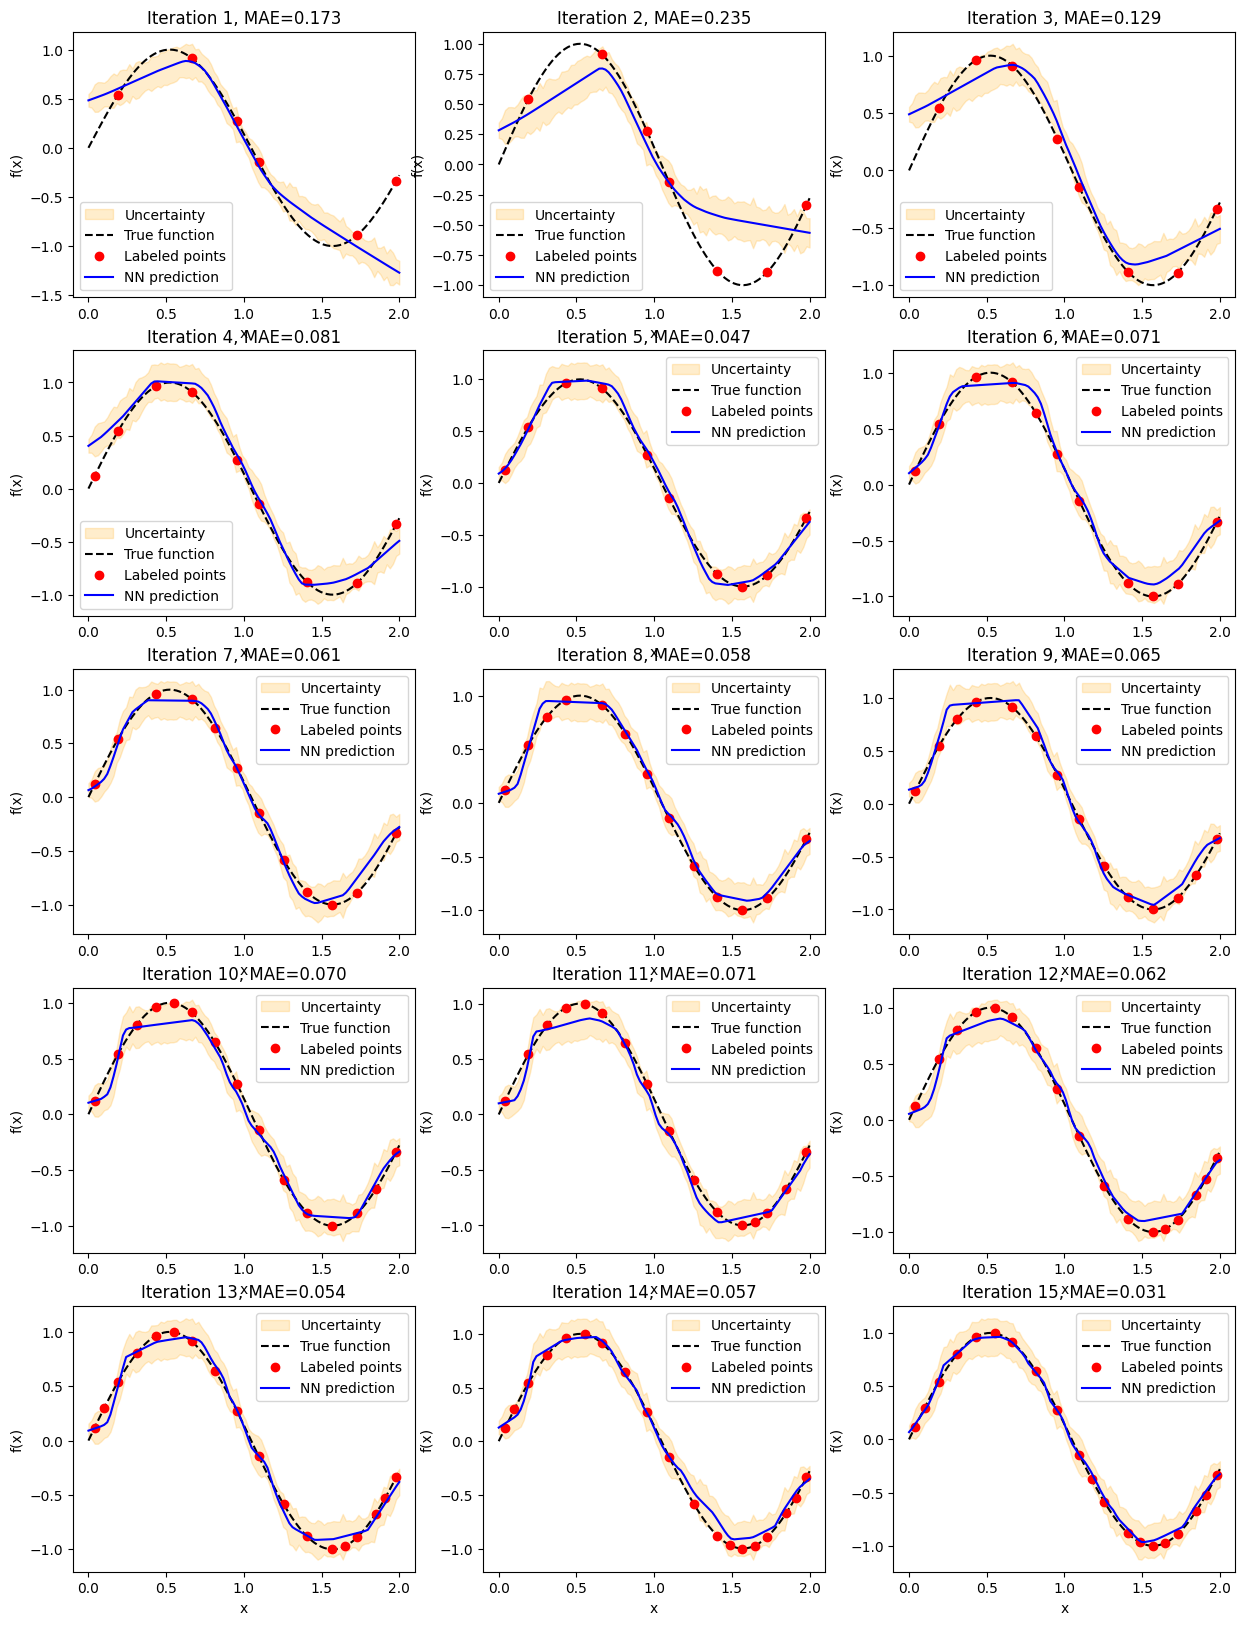

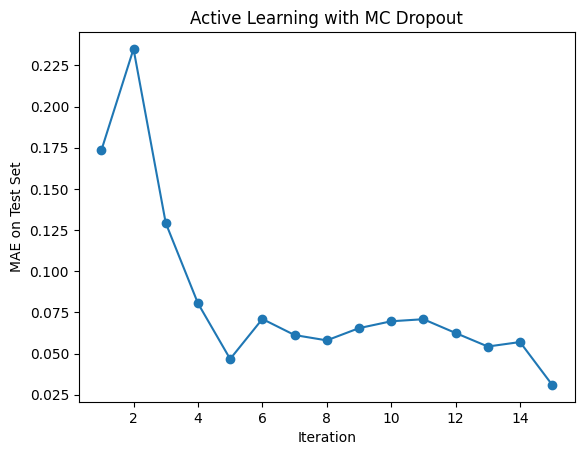

In [12]:

# Initialize labeled/unlabeled pools
idx = np.random.choice(len(X), 5, replace=False)
X_labeled, y_labeled = X[idx], y[idx]
X_unlabeled = np.delete(X, idx, axis=0)
y_unlabeled = np.delete(y, idx, axis=0)

# Convert to torch tensors
X_labeled_t = torch.tensor(X_labeled, dtype=torch.float32)
y_labeled_t = torch.tensor(y_labeled, dtype=torch.float32)
X_unlabeled_t = torch.tensor(X_unlabeled, dtype=torch.float32)


# Evertyhing is the same except we add max-min sampling now
num_iter_al = 15
mc_samples = 50  # for MC dropout
alpha_diversity = 0.5  # weight for diversity (0=only uncertainty, 1=only diversity)

model = FNN()
mae_list = []

# setting up the plotting
nx_panel = 3
ny_panel = num_iter_al//nx_panel + int(bool(num_iter_al%nx_panel))
fig, axes = plt.subplots(ny_panel, nx_panel, figsize=(nx_panel*5, ny_panel*4))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for iteration in range(num_iter_al):
    # Train NN
    train_nn(model, X_labeled_t, y_labeled_t)

    # MC Dropout predictions (uncertainty)
    model.train()  # keep dropout active
    preds = []
    for _ in range(mc_samples):
        preds.append(model(X_unlabeled_t).detach().numpy())
    preds = np.array(preds).squeeze()
    mean_pred = preds.mean(axis=0)
    std_pred = preds.std(axis=0)

    # Diversity score: distance to closest labeled point
    dist_matrix = cdist(X_unlabeled, X_labeled)  # Euclidean distance
    diversity_score = dist_matrix.min(axis=1)

    # Combine uncertainty and diversity
    combined_score = (1-alpha_diversity)*std_pred + alpha_diversity*diversity_score

    # Select next point
    query_idx = np.argmax(combined_score)
    X_new = X_unlabeled[query_idx:query_idx+1]
    y_new = y_unlabeled[query_idx:query_idx+1]

    # Add new point to labeled set
    X_labeled = np.vstack([X_labeled, X_new])
    y_labeled = np.vstack([y_labeled, y_new])
    X_labeled_t = torch.tensor(X_labeled, dtype=torch.float32)
    y_labeled_t = torch.tensor(y_labeled, dtype=torch.float32)

    # Remove from unlabeled pool
    X_unlabeled = np.delete(X_unlabeled, query_idx, axis=0)
    y_unlabeled = np.delete(y_unlabeled, query_idx, axis=0)
    X_unlabeled_t = torch.tensor(X_unlabeled, dtype=torch.float32)

    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        y_test_pred = model(torch.tensor(X_test, dtype=torch.float32)).numpy()
    mae = np.mean(np.abs(y_test_pred - y_test))
    mae_list.append(mae)

    # Plot current iteration
    ax = axes[iteration]
    ax.fill_between(X_test.squeeze(),
                     y_test_pred.squeeze()-2*test_std,
                     y_test_pred.squeeze()+2*test_std,
                     alpha=0.2, color='orange', label='Uncertainty')
    ax.plot(X_test, y_test, 'k--', label='True function')
    ax.plot(X_labeled, y_labeled, 'ro', label='Labeled points')
    ax.plot(X_test, y_test_pred, 'b-', label='NN prediction')
    ax.set_title(f'Iteration {iteration+1}, MAE={mae:.3f}')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()

# Plot MAE trend
plt.figure()
plt.plot(range(1, num_iter_al+1), mae_list, 'o-')
plt.xlabel('Iteration')
plt.ylabel('MAE on Test Set')
plt.title('Active Learning with MC Dropout')